# Overview of Pgmpy

[Pgmpy](https://github.com/pgmpy/pgmpy) is a Python package for working with Bayesian Networks and related models, such as Directed Acyclic Graphs, Dynamic Bayesian Networks, and Conditional Random Fields. It combines features from both causal inference and probabilistic inference literatures to allow users to seamlessly work between both. It implements algorithms for structure learning/causal discovery, parameter estimation, probabilistic and causal inference, and simulations.

Follow the [instruction](https://pgmpy.org/started/install.html) to install the package [pgmpy](https://github.com/pgmpy/pgmpy). 

In [40]:
#!pip install pgmpy

In [41]:
from IPython.display import Image

from pgmpy.example_models import load_model
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.estimators import MaximumLikelihoodEstimator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

### Lung Cancer

A patient has been suffering from shortness of breath (called dyspnoea) and visits the doctor, worried that he has lung cancer. The doctor knows that other diseases, such as tuberculosis and bronchitis, are possible causes, as well as lung cancer. She also knows that other relevant information includes whether or not the patient is a smoker (increasing the chances of cancer and bronchitis) and what sort of air pollution he has been exposed to. A positive X-ray would indicate either TB or lung cancer.

In [42]:
# Load the model
cancer_model = load_model("bnlearn/cancer")

## I. Fundamentals of the Probability Theory

### Random Variable
Random variable is a function that associates each outcome in a sample space $\Omega$ with a value.

| Random Variable | Values |
| --- | --- |
| Pollution | {low, high} |
| Smoker | {True, False} |
| Cancer | {True, False} |
| Dyspnoea | {True, False} |
| Xray | {positive, negative} |

In [43]:
# Show the involved random variables
list(cancer_model.nodes())

['Pollution', 'Smoker', 'Cancer', 'Xray', 'Dyspnoea']

### Joint Distribution

P(Xray, Dyspnoea, Cancer, Pollution, Smoker)=P(X𝑟𝑎𝑦 |𝐶𝑎𝑛𝑐𝑒𝑟)𝑃(𝐷𝑦𝑠𝑝𝑛𝑜𝑒𝑎 | 𝐶𝑎𝑛𝑐𝑒𝑟)𝑃(𝐶𝑎𝑛𝑐𝑒𝑟│𝑃𝑜𝑙𝑙𝑢𝑡𝑖𝑜𝑛, 𝑆𝑚𝑜𝑘𝑒𝑟)
𝑃(𝑃𝑜𝑙𝑙𝑢𝑡𝑖𝑜𝑛)𝑃(𝑆𝑚𝑜𝑘𝑒𝑟)

### Conditional Probability Distribution

cancer_model.get_cpds() returns a list of conditional probability distributions (CPDs). 

In [44]:
for cpd in cancer_model.get_cpds():
    print(cpd)

+---------------+----------------+----------------+-----------------+-----------------+
| Pollution     | Pollution(low) | Pollution(low) | Pollution(high) | Pollution(high) |
+---------------+----------------+----------------+-----------------+-----------------+
| Smoker        | Smoker(True)   | Smoker(False)  | Smoker(True)    | Smoker(False)   |
+---------------+----------------+----------------+-----------------+-----------------+
| Cancer(True)  | 0.03           | 0.001          | 0.05            | 0.02            |
+---------------+----------------+----------------+-----------------+-----------------+
| Cancer(False) | 0.97           | 0.999          | 0.95            | 0.98            |
+---------------+----------------+----------------+-----------------+-----------------+
+-----------------+--------------+---------------+
| Cancer          | Cancer(True) | Cancer(False) |
+-----------------+--------------+---------------+
| Dyspnoea(True)  | 0.65         | 0.3           |
+---

𝑃(𝑃𝑜𝑙𝑙𝑢𝑡𝑖𝑜𝑛=𝑙𝑜𝑤, 𝑆𝑚𝑜𝑘𝑒𝑟=𝑇𝑟𝑢𝑒, 𝐶𝑎𝑛𝑐𝑒𝑟=𝑇𝑟𝑢𝑒, 𝐷𝑦𝑠𝑝𝑛𝑜𝑒𝑎=𝐹𝑎𝑙𝑠𝑒, 𝑋𝑟𝑎𝑦=positive)=

In [45]:
0.9 * 0.3 * 0.03 * 0.35 * 0.9

0.0025515

### Excercise

Use the above CPD tables to compute the following probabilities.

(A) 𝑃(𝑃𝑜𝑙𝑙𝑢𝑡𝑖𝑜𝑛=ℎ𝑖𝑔ℎ, 𝑆𝑚𝑜𝑘𝑒𝑟=𝑇𝑟𝑢𝑒, 𝐶𝑎𝑛𝑐𝑒𝑟=𝑇𝑟𝑢𝑒, 𝐷𝑦𝑠𝑝𝑛𝑜𝑒𝑎=True, 𝑋𝑟𝑎𝑦=positive) = 

In [46]:
0.1 * 0.3 * 0.05 * 0.65 * 0.9

0.0008775

In [47]:
# Get joint probability
cancerTrue = cancer_model.get_state_probability({'Pollution': 'high', 'Smoker': 'True', 'Cancer': 'True', 'Dyspnoea': 'True', 'Xray':'positive'})
cancerTrue

np.float64(0.0008775)

(B) P(𝐶𝑎𝑛𝑐𝑒𝑟=𝑡𝑟𝑢𝑒| 𝑋𝑟𝑎𝑦 = positive, 𝐷𝑦𝑠𝑝𝑛𝑜𝑒𝑎=𝑇𝑟𝑢𝑒, 𝑃𝑜𝑙𝑙𝑢𝑡𝑖𝑜𝑛=ℎ𝑖𝑔ℎ, 𝑆𝑚𝑜𝑘𝑒𝑟=𝑇𝑟𝑢𝑒) = 

In [48]:
pCancerTrue = 0.1 * 0.3 * 0.05 * 0.65 * 0.9
pCancerFalse =  0.1 * 0.3 * 0.95 * 0.3 * 0.2
pCancerTrue / (pCancerTrue + pCancerFalse)

0.3391304347826088

In [49]:
# Get joint probability
cancerMarginal = cancer_model.get_state_probability({'Pollution': 'high', 'Smoker': 'True', 'Dyspnoea': 'True', 'Xray':'positive'})
cancerTrue / cancerMarginal

np.float64(0.3391304347826088)

## II. Design Bayesian Networks

### Basic operations
#### Visualisation

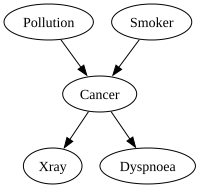

In [50]:
from IPython.display import display

def visualize(bayesian_net):
    viz = bayesian_net.to_graphviz()
    viz.layout(prog="dot")
    display(viz)

visualize(cancer_model)

#### Attributes of a Bayesian Network

In [51]:
# Get all edges
list(cancer_model.edges())

[('Pollution', 'Cancer'),
 ('Smoker', 'Cancer'),
 ('Cancer', 'Xray'),
 ('Cancer', 'Dyspnoea')]

In [52]:
# Get all leaf nodes
cancer_model.get_leaves()

['Xray', 'Dyspnoea']

In [53]:
# Get the root nodes
cancer_model.get_roots()

['Pollution', 'Smoker']

In [54]:
# Get parents of a specific node
cancer_model.get_parents('Cancer')

['Pollution', 'Smoker']

In [55]:
# Get children of a specific node
cancer_model.get_children('Cancer')

['Xray', 'Dyspnoea']

In [56]:
cancer_model.get_independencies()

(Dyspnoea ⟂ Xray | Cancer)
(Dyspnoea ⟂ Smoker | Cancer)
(Pollution ⟂ Smoker)
(Pollution ⟂ Xray | Cancer)
(Smoker ⟂ Xray | Cancer)
(Dyspnoea ⟂ Pollution | Cancer)

#### Create a Bayesian Network from Scratch Manually

In [57]:
# Step 1: Define the network structure.
cancer_bn = DiscreteBayesianNetwork(
    [
        ("Pollution", "Cancer"),
        ("Smoker", "Cancer"),
        ("Cancer", "Xray"),
        ("Cancer", "Dyspnoea"),
    ]
)

# Step 2: Define the CPDs.
cpd_poll = TabularCPD(variable="Pollution", variable_card=2, values=[[0.9], [0.1]])
cpd_smoke = TabularCPD(variable="Smoker", variable_card=2, values=[[0.3], [0.7]])
cpd_cancer = TabularCPD(
    variable="Cancer",
    variable_card=2,
    values=[[0.03, 0.05, 0.001, 0.02], [0.97, 0.95, 0.999, 0.98]],
    evidence=["Smoker", "Pollution"],
    evidence_card=[2, 2],
)
cpd_xray = TabularCPD(
    variable="Xray",
    variable_card=2,
    values=[[0.9, 0.2], [0.1, 0.8]],
    evidence=["Cancer"],
    evidence_card=[2],
)
cpd_dysp = TabularCPD(
    variable="Dyspnoea",
    variable_card=2,
    values=[[0.65, 0.3], [0.35, 0.7]],
    evidence=["Cancer"],
    evidence_card=[2],
)

# Step 3: Add the CPDs to the model.
cancer_bn.add_cpds(cpd_poll, cpd_smoke, cpd_cancer, cpd_xray, cpd_dysp)

# Step 4: Check if the model is correctly defined.
cancer_bn.check_model()

True

#### Create a Bayesian network with random CPDs.

In [58]:
cancer_random = DiscreteBayesianNetwork(
    [
        ("Pollution", "Cancer"),
        ("Smoker", "Cancer"),
        ("Cancer", "Xray"),
        ("Cancer", "Dyspnoea"),
    ]
)

cancer_random.get_random_cpds(n_states=3, inplace=True)

# Access attributes of the model
nodes = cancer_random.nodes()
edges = cancer_random.edges()
cpds = cancer_random.get_cpds()

print(f"Nodes in the model: {nodes} \n")
print(f"Edges in the model: {edges} \n")
print(f"CPDs in the model: ")
for cpd in cpds:
    print(cpd)

Nodes in the model: ['Pollution', 'Cancer', 'Smoker', 'Xray', 'Dyspnoea'] 

Edges in the model: [('Pollution', 'Cancer'), ('Cancer', 'Xray'), ('Cancer', 'Dyspnoea'), ('Smoker', 'Cancer')] 

CPDs in the model: 
+--------------+-----------+
| Pollution(0) | 0.595799  |
+--------------+-----------+
| Pollution(1) | 0.37282   |
+--------------+-----------+
| Pollution(2) | 0.0313807 |
+--------------+-----------+
+-----------+---------------------+---------------------+-----+--------------------+---------------------+
| Pollution | Pollution(0)        | Pollution(0)        | ... | Pollution(2)       | Pollution(2)        |
+-----------+---------------------+---------------------+-----+--------------------+---------------------+
| Smoker    | Smoker(0)           | Smoker(1)           | ... | Smoker(1)          | Smoker(2)           |
+-----------+---------------------+---------------------+-----+--------------------+---------------------+
| Cancer(0) | 0.2656511971858521  | 0.35616951244379

### Case Study: Student

A student's grade is influenced not just by his/her intelligence but also by the difficulty of the course. The intelligence can also be reflected by his/her SAT score.
The student approaches their professor for a recommendation letter. The professor, however, cannot remember the names of her students. She relies solely on the student's grade to write the letter. The actual quality of the letter depends probabilistically on the student's grade.

#### Random Variables

* Student’s intelligence (I): $Val(I) = \{low, high\}$;
* Course difficulty (D): $Val(D) = \{easy, hard\}$;
* Grade (G): $Val(G) = \{A, B, C\}$;
* SAT score (S): $Val(S) = \{low, high\}$
* Quality of the recommendation letter (L): $Val(L) = \{weak, strong\}$.

#### Dependencies and Independencies

1. "A student's grade is influenced not just by his/her intelligence but also by the difficulty of the course."  $\implies P(G | I, D)$
2. "The intelligence can also be reflected by his/her SAT score." $\implies P(S | I)$, $S \perp\!\!\!\!\perp D | I$, $S \perp\!\!\!\!\perp G | I$ and $S \perp\!\!\!\!\perp L | I$.
3. "She relies solely on the student's grade to write the letter." $\implies P(L | G)$, $L \perp\!\!\!\!\perp I | G$, $L \perp\!\!\!\!\perp S | G$ and $L \perp\!\!\!\!\perp D | G$.

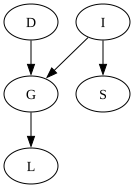

In [59]:
student_model = DiscreteBayesianNetwork([('D', 'G'), ('I', 'G'), ('G', 'L'), ('I', 'S')])
visualize(student_model)

#### CPDs

Two approaches to determine CPDs:
* Use heuristics, if there are no relevant datasets.
* Learn CPDs from data.

We might believe that 
* The probability that the course is difficult is higher than 50%.
* The proportion of smart students in the class is approximately 30%.
* A smart student in an easy class is 90 percent likely to get an A, 8 percent likely to get a B, and 2 percent likely to get a C.
* ...

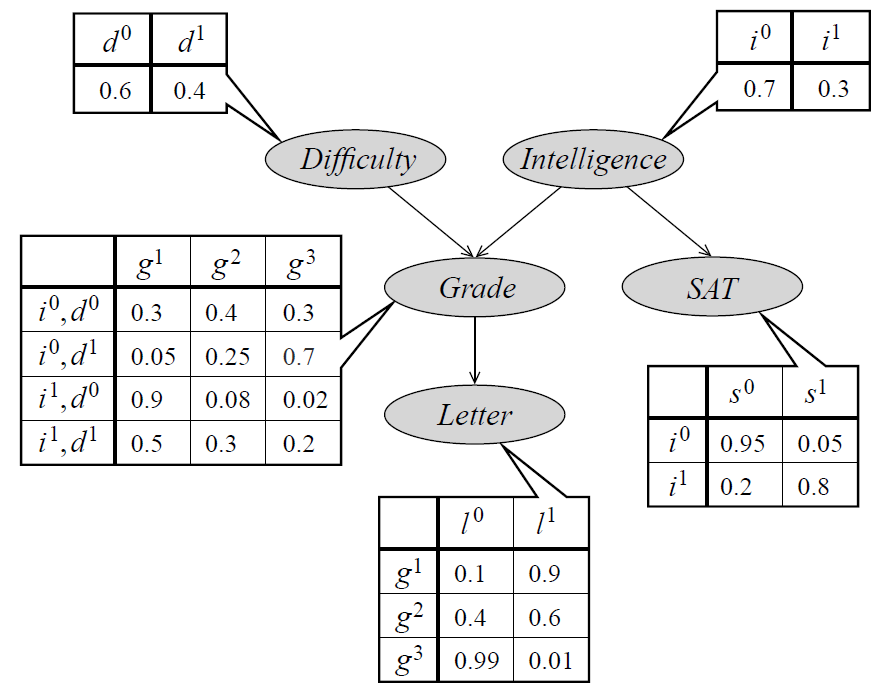

In [60]:
cpd_d_sn = TabularCPD(variable='D', variable_card=2, values=[[0.6], [0.4]], state_names={'D': ['Easy', 'Hard']})
cpd_i_sn = TabularCPD(variable='I', variable_card=2, values=[[0.7], [0.3]], state_names={'I': ['Low', 'High']})
cpd_g_sn = TabularCPD(variable='G', variable_card=3,
                      values=[[0.3, 0.05, 0.9,  0.5],
                              [0.4, 0.25, 0.08, 0.3],
                              [0.3, 0.7,  0.02, 0.2]],
                      evidence=['I', 'D'],
                      evidence_card=[2, 2],
                      state_names={'G': ['A', 'B', 'C'],
                                   'I': ['Low', 'High'],
                                   'D': ['Easy', 'Hard']})

cpd_l_sn = TabularCPD(variable='L', variable_card=2,
                      values=[[0.1, 0.4, 0.99],
                              [0.9, 0.6, 0.01]],
                      evidence=['G'],
                      evidence_card=[3],
                      state_names={'L': ['Weak', 'Strong'],
                                   'G': ['A', 'B', 'C']})

cpd_s_sn = TabularCPD(variable='S', variable_card=2,
                      values=[[0.95, 0.2],
                              [0.05, 0.8]],
                      evidence=['I'],
                      evidence_card=[2],
                      state_names={'S': ['Low', 'High'],
                                   'I': ['Low', 'High']})

# These defined CPDs can be added to the model. Since, the model already has CPDs associated to variables, it will
# show warning that pmgpy is now replacing those CPDs with the new ones.
student_model.add_cpds(cpd_d_sn, cpd_i_sn, cpd_g_sn, cpd_l_sn, cpd_s_sn)
student_model.check_model()

True

* **Evidential reasoning**: reason from effects to causes.
    * Mark gets a weak recommendation letter from his professor in FIT5149. The probability that Mark has high intelligence is only 14%, namely 𝑃(𝐼=ℎ𝑖𝑔ℎ│𝐿=𝑤𝑒𝑎𝑘)=0.14. If he has a grade C, 𝑃(𝐼=ℎ𝑖𝑔ℎ│𝐿=𝑤𝑒𝑎𝑘, 𝐺=𝐶)=0.079, which is similar to 𝑃(𝐼=ℎ𝑖𝑔ℎ│𝐺=𝐶).
    * If Mark has a high SAT score, 𝑃(𝐼=ℎ𝑖𝑔ℎ│𝑆=ℎ𝑖𝑔ℎ, 𝐺=𝐶)=0.578. Students with low intelligence are extremely unlikely to get good scores on their SAT.
* **Explaining away**: different causes of the same effect can interact.
    * George gets a B in FIT5149, 𝑃(𝐼=ℎ𝑖𝑔ℎ│𝐺=𝐵)=0.175.
    * FIT5149 is hard, 𝑃(𝐼=ℎ𝑖𝑔ℎ│𝐺=𝐵, 𝐷=ℎ𝑎𝑟𝑑)=0.34. It explains away the poor grade via the difficulty of the unit.

### Activity I: Design a Bayesian Network about Visits to Asia 

**Scenario**: Shortness-of-breath (dyspnoea) may be due to tuberculosis, lung cancer or bronchitis, or none of them, or more than one of them. A recent visit to Asia increases the chances of tuberculosis, while smoking is known to be a risk factor for both lung cancer and bronchitis. The results of a single chest X-ray do not discriminate between lung cancer and tuberculosis, as neither does the presence or absence of dyspnoea.

**Identify random variables and design a Bayesian structure for this scenario.**

* Dyspnoea (D)
* Tuberculosis (T)
* Lung cancer (L)
* Bronchitis (B)
* Visit to Asia (A)
* Smoking (S)
* Xray (X)
* Either (E)

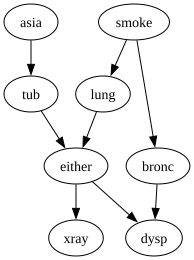

In [61]:
asia_model = load_model("bnlearn/asia")
visualize(asia_model)

## III. Demo: D-Separation

* Are A and C d-separated by the empty set ?
* Are A and C d-separated by 𝐸?
* Are A and C d-separated by F?
* Are A and C d-separated by{E,F}?

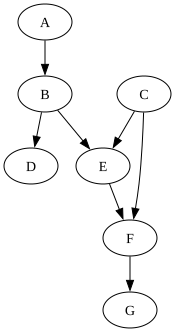

In [62]:
dsep_model = DiscreteBayesianNetwork([('A', 'B'), ('B', 'D'), ('B', 'E'), ('E', 'F'), ('F','G'),('C','E'), ('C','F')])
visualize(dsep_model)

Instead of D-Separation, the code returns if the variables are d-connected, the opposite of D-separation. If two variables are d-connected, they are not d-separated.

In [63]:
print(not dsep_model.is_dconnected('A', 'C'))
print(not dsep_model.is_dconnected('A', 'C', observed=['E']))
print(not dsep_model.is_dconnected('A', 'C', observed=['F']))
print(not dsep_model.is_dconnected('A', 'C', observed=['E', 'F']))

True
False
False
False


## IV. Demo: Building a Deep Bayesian Network with pomegranate

### What is pomegranate?

[pomegranate](https://github.com/jmschrei/pomegranate) is a Python library for probabilistic models (Bayesian networks, hidden Markov models, mixture models, factor graphs). Since version 1.0 it is built on **PyTorch**: every distribution and every model is a `torch.nn.Module`, so a model can be moved to a GPU, saved with `state_dict()`, and placed in the same pipeline as a neural network.

Key differences from pgmpy for this unit:

| | pgmpy | pomegranate (>= 1.0) |
| --- | --- | --- |
| Variables | named nodes (`'Cancer'`) with named states | columns of an integer tensor; state `k` is encoded as the integer `k` |
| CPDs | `TabularCPD` | `Categorical` (root) and `ConditionalCategorical` (child) |
| Structure | list of edges `('Smoker', 'Cancer')` | `edges=[(smoke, cancer)]` between distribution objects, or `structure=((), (0,), ...)` with parent indices |
| Parameter learning | `MaximumLikelihoodEstimator` | `model.fit(X)` |
| Inference | `VariableElimination`, `predict` | `model.predict_proba(X_masked)` / `model.predict(X_masked)`, where missing values are marked with a `MaskedTensor` |
| Structure learning | `PC`, `HillClimbSearch` | `BayesianNetwork(algorithm='chow-liu' | 'exact')` |

Its Bayesian networks currently support categorical nodes only. Continuous inputs such as images or signals therefore need to be turned into categorical variables first, which is exactly what a **deep Bayesian network** does: a neural network learns the mapping from raw data to a variable, and the BN reasons over that variable together with the rest of the domain knowledge.

Install it with `pip install pomegranate` (this also installs PyTorch).

In [64]:
#!pip install pomegranate

In [79]:
import warnings
import numpy as np
import torch
from torch.masked import MaskedTensor

from pomegranate.bayesian_network import BayesianNetwork
from pomegranate.distributions import Categorical, ConditionalCategorical

warnings.filterwarnings("ignore", category=UserWarning)   # MaskedTensor is still marked as a prototype feature
torch.manual_seed(0)
np.random.seed(0)

### Step 1: Data

We reuse the Asia network from Activity I to simulate a patient dataset, then encode the states as integers, because pomegranate works on integer tensors rather than data frames with named states.

In [80]:
asia_dataset = asia_model.simulate(n_samples=int(1e4), seed=0)
asia_train, asia_test = train_test_split(asia_dataset, test_size=0.1, random_state=0)

columns = list(asia_model.nodes())          # column order used by pomegranate
state_index = {'no': 0, 'yes': 1}

def encode(df):
    coded = df[columns].apply(lambda col: col.astype(str).map(state_index))
    return torch.tensor(coded.to_numpy(dtype=np.int64))

X_train, X_test = encode(asia_train), encode(asia_test)
print(columns)
print(X_train[:5])

  0%|          | 0/8 [00:00<?, ?it/s]

['asia', 'tub', 'smoke', 'lung', 'bronc', 'either', 'xray', 'dysp']
tensor([[0, 0, 1, 0, 1, 0, 0, 1],
        [0, 0, 1, 0, 1, 0, 0, 1],
        [0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]])


### Step 2: A raw, high-dimensional observation

In the simulated dataset the X-ray result is already a clean categorical variable. In practice the doctor sees an **image**, not a label. To mimic this, we replace the `xray` column with a synthetic 8 x 8 grey-level image per patient: a positive X-ray adds a bright blob to a noisy background. A tabular CPD cannot take 64 continuous pixel values as a parent, so the BN cannot use this observation directly.

In [81]:
def make_xray_images(xray_states, size=8, noise=2.0):
    """One noisy size x size image per patient; a positive X-ray (state 1) adds a bright blob."""
    n = len(xray_states)
    imgs = np.random.randn(n, size, size) * noise
    yy, xx = np.mgrid[0:size, 0:size]
    blob = np.exp(-((yy - size / 2) ** 2 + (xx - size / 2) ** 2) / 4.0)
    imgs[xray_states == 1] += 1.5 * blob
    return torch.tensor(imgs, dtype=torch.float32).reshape(n, -1)

xray_col = columns.index('xray')
img_train = make_xray_images(X_train[:, xray_col].numpy())
img_test = make_xray_images(X_test[:, xray_col].numpy())
print(img_train.shape)   # 9000 patients x 64 pixels

torch.Size([9000, 64])


### Step 3: Learn a feature with a neural network

A small feed-forward network (the *encoder*) is trained to map an image to the categorical X-ray state. Its output is the **learned feature** that will become a node of the Bayesian network. Any encoder can be used here (a CNN for real radiographs, a transformer for clinical notes); only the interface matters: raw input in, categorical variable out.

In [82]:
class XrayEncoder(torch.nn.Module):
    def __init__(self, n_pixels=64, n_hidden=32, n_states=2):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n_pixels, n_hidden), torch.nn.ReLU(),
            torch.nn.Linear(n_hidden, n_states))

    def forward(self, x):
        return self.net(x)          # logits over the X-ray states

encoder = XrayEncoder()
optimiser = torch.optim.Adam(encoder.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(200):
    optimiser.zero_grad()
    loss = loss_fn(encoder(img_train), X_train[:, xray_col])
    loss.backward()
    optimiser.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch}: loss = {loss.item():.3f}")

with torch.no_grad():
    feat_train = encoder(img_train).argmax(dim=1)
    feat_test = encoder(img_test).argmax(dim=1)

print("Encoder accuracy on test images:", (feat_test == X_test[:, xray_col]).float().mean().item())

epoch 0: loss = 0.840
epoch 50: loss = 0.160
epoch 100: loss = 0.128
epoch 150: loss = 0.091
Encoder accuracy on test images: 0.8859999775886536


### Step 4: the learned feature as input of a Bayesian network

We keep the DAG of the Asia network but feed the encoder's prediction in place of the true X-ray state. `structure` lists, for every column, the indices of its parent columns; `fit` then estimates all CPDs by maximum likelihood, as `MaximumLikelihoodEstimator` did in pgmpy.

In [83]:
# Replace the true X-ray state by the learned feature
Z_train, Z_test = X_train.clone(), X_test.clone()
Z_train[:, xray_col] = feat_train
Z_test[:, xray_col] = feat_test

# Same DAG as asia_model, expressed as parent indices
structure = tuple(tuple(columns.index(p) for p in asia_model.get_parents(v)) for v in columns)
print(structure)

deep_bn = BayesianNetwork(structure=structure)
deep_bn.fit(Z_train)

((), (0,), (), (2,), (2,), (3, 1), (5,), (4, 5))


BayesianNetwork(
  (distributions): ModuleList(
    (0): Categorical()
    (1): ConditionalCategorical(
      (probs): ParameterList(  (0): Parameter containing: [torch.float32 of size 2x2])
      (_w_sum): [tensor([0., 0.])]
      (_xw_sum): [tensor([[0., 0.],
              [0., 0.]])]
      (_log_probs): [tensor([[-0.0124, -4.3933],
              [-0.0408, -3.2189]])]
    )
    (2): Categorical()
    (3): ConditionalCategorical(
      (probs): ParameterList(  (0): Parameter containing: [torch.float32 of size 2x2])
      (_w_sum): [tensor([0., 0.])]
      (_xw_sum): [tensor([[0., 0.],
              [0., 0.]])]
      (_log_probs): [tensor([[-0.0086, -4.7572],
              [-0.1006, -2.3464]])]
    )
    (4): ConditionalCategorical(
      (probs): ParameterList(  (0): Parameter containing: [torch.float32 of size 2x2])
      (_w_sum): [tensor([0., 0.])]
      (_xw_sum): [tensor([[0., 0.],
              [0., 0.]])]
      (_log_probs): [tensor([[-0.3573, -1.2026],
              [-0.9247, 

In [84]:
# Compare a learned CPD with the true one: P(lung | smoke), rows = smoke state, columns = lung state
print(deep_bn.distributions[columns.index('lung')].probs[0])
print(asia_model.get_cpds('lung'))

Parameter containing:
tensor([[0.9914, 0.0086],
        [0.9043, 0.0957]])
+-----------+------------+-----------+
| smoke     | smoke(yes) | smoke(no) |
+-----------+------------+-----------+
| lung(yes) | 0.1        | 0.01      |
+-----------+------------+-----------+
| lung(no)  | 0.9        | 0.99      |
+-----------+------------+-----------+


**Inference.** Missing values are marked with a `MaskedTensor`; `predict` fills them with the most probable state, `predict_proba` returns the posterior of every column. Here we diagnose *either* (tuberculosis or lung cancer) from the visit to Asia, smoking, bronchitis, dyspnoea, and the X-ray **image** (through the encoder), hiding the three disease variables.

In [85]:
hidden = [columns.index(v) for v in ('tub', 'lung', 'either')]
either_col = columns.index('either')

Z_query = Z_test.clone()
Z_query[:, hidden] = -1
Z_query = MaskedTensor(Z_query, mask=(Z_query != -1))

either_pred = deep_bn.predict(Z_query)[:, either_col]
print(classification_report(X_test[:, either_col].numpy(), either_pred.numpy(), target_names=['no', 'yes']))

              precision    recall  f1-score   support

          no       0.96      0.97      0.97       937
         yes       0.47      0.35      0.40        63

    accuracy                           0.93      1000
   macro avg       0.71      0.66      0.68      1000
weighted avg       0.93      0.93      0.93      1000



## V. After-Class Activity: pomegranate Crash Course

Work through the cells below in order. Each part introduces one feature of pomegranate on the lung-cancer network from Part I, so that you can check your answers against the pgmpy results above. Parts A to C are worked examples; parts D to F are for you to complete.

### A. Build the lung-cancer network by hand

State encoding used throughout: `Pollution` low = 0, high = 1; `Smoker`, `Cancer`, `Dyspnoea` False = 0, True = 1; `Xray` negative = 0, positive = 1.

* A root node is a `Categorical` with one row of probabilities, `[[P(state 0), P(state 1), ...]]`.
* A child node is a `ConditionalCategorical` whose table has one axis per parent (in the order of the `edges` you declare) followed by one axis for the child. For `Cancer` with parents `Pollution` and `Smoker`, entry `[p][s]` is the row $P(\text{Cancer} \mid \text{Pollution}=p, \text{Smoker}=s)$.
* The table is wrapped in an outer list because `ConditionalCategorical` can hold several tables.

In [74]:
pollution = Categorical([[0.9, 0.1]])
smoker = Categorical([[0.7, 0.3]])
cancer = ConditionalCategorical([[[[0.999, 0.001],     # Pollution = low,  Smoker = False
                                   [0.97, 0.03]],      # Pollution = low,  Smoker = True
                                  [[0.98, 0.02],       # Pollution = high, Smoker = False
                                   [0.95, 0.05]]]])    # Pollution = high, Smoker = True
xray = ConditionalCategorical([[[0.8, 0.2],            # Cancer = False
                                [0.1, 0.9]]])          # Cancer = True
dyspnoea = ConditionalCategorical([[[0.7, 0.3],
                                    [0.35, 0.65]]])

cancer_bn = BayesianNetwork(
    distributions=[pollution, smoker, cancer, xray, dyspnoea],
    edges=[(pollution, cancer), (smoker, cancer), (cancer, xray), (cancer, dyspnoea)])

# Column order of the data tensor = order of `distributions`
cancer_columns = ['Pollution', 'Smoker', 'Cancer', 'Xray', 'Dyspnoea']

### B. Joint probabilities

`probability` and `log_probability` evaluate the joint distribution for complete rows. Compare with exercise (A) in Part I, where the same value was computed by hand as $0.1 \times 0.3 \times 0.05 \times 0.65 \times 0.9$.

In [75]:
row = torch.tensor([[1, 1, 1, 1, 1]])   # Pollution = high, Smoker = True, Cancer = True, Xray = positive, Dyspnoea = True
print(cancer_bn.probability(row))
print(0.1 * 0.3 * 0.05 * 0.65 * 0.9)

tensor([0.0009])
0.0008775


### C. Queries with missing values

Mark unknown entries with any value and a `False` mask. `predict_proba` returns one tensor per column with the posterior of each state. The example answers exercise (B): $P(\text{Cancer} \mid \text{Xray}=\text{positive}, \text{Dyspnoea}=\text{True}, \text{Pollution}=\text{high}, \text{Smoker}=\text{True})$.

In [76]:
query = torch.tensor([[1, 1, -1, 1, 1]])
query = MaskedTensor(query, mask=(query != -1))

posteriors = cancer_bn.predict_proba(query)
print(posteriors[cancer_columns.index('Cancer')])   # [P(Cancer = False | e), P(Cancer = True | e)]

tensor([[0.6609, 0.3391]])


### D. Sampling and parameter learning (your turn)

1. Draw 5,000 samples from `cancer_bn` with `cancer_bn.sample(5000)`.
2. Create a new network with the same DAG but no CPDs, using the `structure` argument (parent indices in the column order above), and fit it to the samples.
3. Print the learned $P(\text{Xray} \mid \text{Cancer})$ with `.distributions[3].probs[0]` and compare with the true table in part A. How close is it? What happens with 50 samples instead of 5,000?

In [77]:
samples = cancer_bn.sample(5000)

# TODO: complete the parent-index structure for [Pollution, Smoker, Cancer, Xray, Dyspnoea]
learned_bn = BayesianNetwork(structure=((), (), (0, 1), (2,), (2,)))
learned_bn.fit(samples)

print(learned_bn.distributions[3].probs[0])

Parameter containing:
tensor([[0.8058, 0.1942],
        [0.1389, 0.8611]])


Practice more in the applied session this week!